In [11]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split

ImportError: cannot import name 'lasso' from 'sklearn.linear_model' (C:\Users\Tejas\anaconda3\Lib\site-packages\sklearn\linear_model\__init__.py)

In [10]:
insurance_data=pd.read_csv("insurance.csv");

x=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]

x=pd.get_dummies(x,columns=["region"],drop_first=True,dtype=int)

x["sex"]=x["sex"].map({"female":1,"male":0})
x["smoker"]=x["smoker"].map({"yes":1,"no":0})

x["age_smoker"]=x["age"]*x["smoker"]
x["bmi_smoker"]=x["bmi"]*x["smoker"]

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)


mean 20922599.87103596
mean 20921803.698431373
mean 20914832.63508914
mean 20908106.77995452
mean 20896130.81113565
mean 20890881.000633497
mean 20886178.83893183
mean 20937537.133939773
mean 21046489.29389078
mean 21196929.86960891
mean 20914832.63508914


<Axes: >

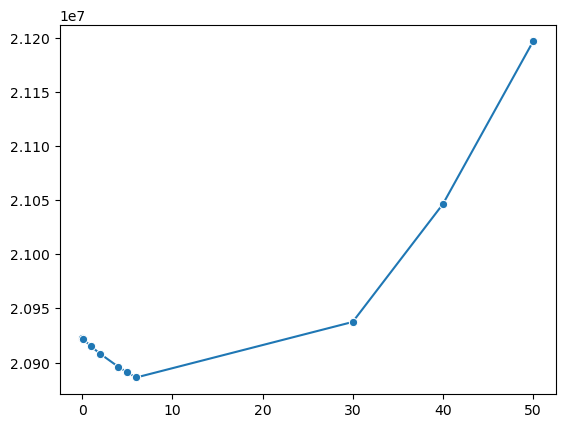

In [16]:
alphas=[0.001,0.1,1,2,4,5,6,30,40,50,1]
mses=[]

import seaborn as sns

for a in alphas:
    
    lasso_model=linear_model.Lasso(alpha=a)
    lasso_model.fit(x_train,y_train)

    y_pred=lasso_model.predict(x_test)
    mse=mean_squared_error(y_test,y_pred)
    print("mean",mse)
    mses.append(mse)

sns.lineplot(x=alphas,y=mses,marker="o")

In [21]:
from sklearn.linear_model import LassoCV
alphas=[0.001,0.1,1,2,4,5,6,30,40,50,1]

lasso_cv_model=LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=100,
    random_state=42
)
lasso_cv_model.fit(x_train,y_train)
print("best alpha:",lasso_cv_model.alpha_)
y_pred=lasso_cv_model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
print("mse=",mse)


best alpha: 0.001
mse= 20889718.149677306


C:\Users\Tejas\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.757e+09, tolerance: 1.242e+07
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Tejas\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.516e+08, tolerance: 1.242e+07
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Tejas\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.055e+08